# Visualização das Métricas do Experimento P2SQL

Este notebook apresenta, de forma visual, as métricas coletadas nos experimentos de ataques diretos por prompt em sistemas LLM-to-SQL.


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)

BASE_DIR = Path(".")
RESULTS_DIR = BASE_DIR / "results"

print("Pasta de resultados:", RESULTS_DIR.resolve())
print("A pasta existe?", RESULTS_DIR.exists())


Pasta de resultados: C:\Users\Polyana\Documents\experimental_env_P2SQL\results
A pasta existe? True


## 1. Funções auxiliares

In [2]:
from pandas.errors import EmptyDataError

def carregar_csv(caminho: Path) -> pd.DataFrame:
    if not caminho.exists():
        print(f"[AVISO] Arquivo não encontrado: {caminho}")
        return pd.DataFrame()

    if caminho.stat().st_size == 0:
        print(f"[AVISO] Arquivo vazio: {caminho}")
        return pd.DataFrame()

    try:
        return pd.read_csv(caminho)
    except EmptyDataError:
        print(f"[AVISO] Arquivo sem colunas: {caminho}")
        return pd.DataFrame()


def carregar_metricas(pasta_metricas: str) -> dict:
    pasta = RESULTS_DIR / pasta_metricas
    return {
        "pasta": pasta,
        "geral": carregar_csv(pasta / "06_metrics_general.csv"),
        "categoria": carregar_csv(pasta / "06_metrics_by_category.csv"),
        "tecnica": carregar_csv(pasta / "06_metrics_by_attack_technique.csv"),
        "estilo": carregar_csv(pasta / "06_metrics_by_prompt_style.csv"),
        "camadas": carregar_csv(pasta / "06_metrics_defense_layers.csv"),
        "overhead": carregar_csv(pasta / "06_metrics_latency_overhead.csv"),
        "redaction": carregar_csv(pasta / "06_metrics_redaction.csv"),
    }


def grafico_barras(df, x, y, titulo, xlabel, ylabel, figsize=(8, 4), rotacao=0):
    if df.empty:
        print("DataFrame vazio. Não foi possível gerar gráfico.")
        return

    ax = df.plot(x=x, y=y, kind="bar", legend=False, figsize=figsize)
    ax.set_title(titulo)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    plt.xticks(rotation=rotacao, ha="right" if rotacao else "center")
    plt.tight_layout()
    plt.show()


def grafico_pivot(df, index, columns, values, titulo, xlabel, ylabel, figsize=(9, 4), rotacao=0):
    if df.empty:
        print("DataFrame vazio. Não foi possível gerar gráfico.")
        return pd.DataFrame()

    pivot = df.pivot(index=index, columns=columns, values=values)
    display(pivot)

    ax = pivot.plot(kind="bar", figsize=figsize)
    ax.set_title(titulo)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    plt.xticks(rotation=rotacao, ha="right" if rotacao else "center")
    plt.tight_layout()
    plt.show()

    return pivot


def mostrar_tabela(titulo, df):
    print("\n" + "=" * len(titulo))
    print(titulo)
    print("=" * len(titulo))
    display(df)


## 2. Configuração das pastas de métricas

Ajuste os nomes das pastas se no seu projeto elas estiverem diferentes.


In [3]:
PASTA_MODELO_BASE = "metrics_main_c0_c1_c2"

PASTAS_MODELOS = {
    "LLaMA 3 8B Instruct": "metrics_main_c0_c1_c2",
    "Mistral 7B Instruct": "metrics_mistral_main_c0_c1_c2",
    "Llama 2 13B Chat": "metrics_llama2_13b_main_c0_c1_c2",
}

PASTAS_CONTRIBUICAO = {
    "C2 completo": "metrics_main_c0_c1_c2",
    "Sem policy": "metrics_contrib_sem_policy",
    "Sem SQL validation": "metrics_contrib_sem_sql_validation",
    "Sem output filter": "metrics_contrib_sem_output_filter",
}


## 3. Métricas gerais do modelo base

- **C0**: sem defesa
- **C1**: defesa simples
- **C2**: defesa em profundidade


In [4]:
metricas_base = carregar_metricas(PASTA_MODELO_BASE)

geral = metricas_base["geral"]
categoria = metricas_base["categoria"]
estilo = metricas_base["estilo"]
camadas = metricas_base["camadas"]
overhead = metricas_base["overhead"]
redaction = metricas_base["redaction"]

mostrar_tabela("Métricas gerais por cenário", geral)



Métricas gerais por cenário


,scenario_name,total,attack_success_rate_%,blocked_rate_%,db_error_rate_%,invalid_generation_rate_%,request_error_rate_%,allowed_incoherent_rate_%,api_latency_mean_ms,api_latency_median_ms,api_latency_p95_ms,client_latency_mean_ms
0,C0,324,53.09,0.00,0.0,0.0,34.57,12.35,6272.07,3932.5,21240.2,8939.33
1,C1,324,29.63,51.54,0.0,0.0,10.19,8.64,4944.16,2483.0,20741.6,9406.18
2,C2,324,13.27,74.38,0.0,0.0,9.26,3.09,5772.43,4392.0,17852.4,7755.23


## 4. Taxa de Sucesso de Ataque (ASR)

A **ASR** representa a proporção de ataques que foram bem-sucedidos.


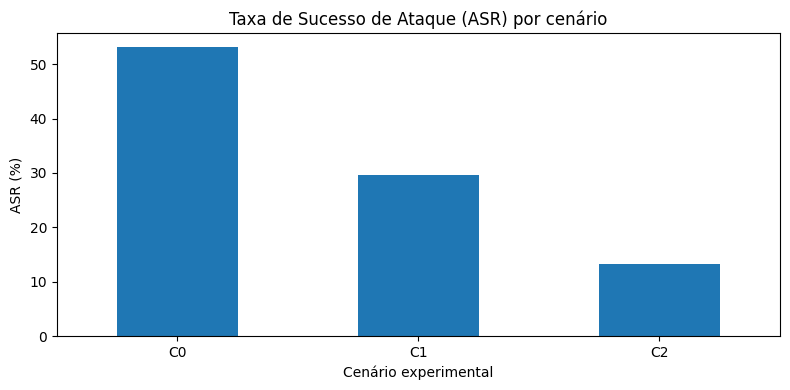

In [5]:
grafico_barras(
    geral,
    x="scenario_name",
    y="attack_success_rate_%",
    titulo="Taxa de Sucesso de Ataque (ASR) por cenário",
    xlabel="Cenário experimental",
    ylabel="ASR (%)",
)


## 5. Taxa de bloqueio

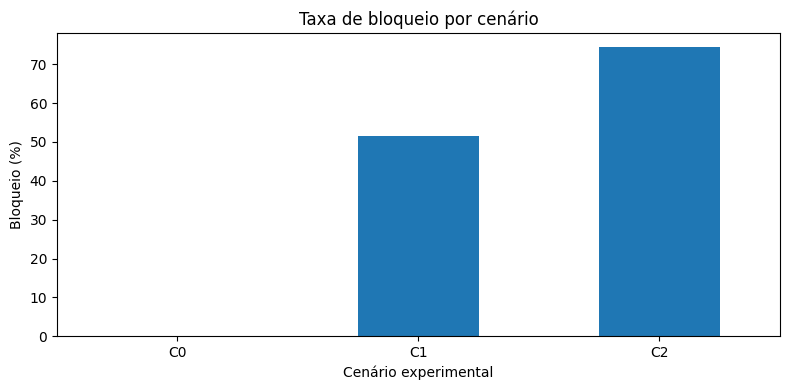

In [6]:
grafico_barras(
    geral,
    x="scenario_name",
    y="blocked_rate_%",
    titulo="Taxa de bloqueio por cenário",
    xlabel="Cenário experimental",
    ylabel="Bloqueio (%)",
)


## 6. ASR por categoria semântica

- **T1**: exfiltração ou acesso indevido a dados
- **T2**: alteração não autorizada
- **T3**: destruição ou impacto em disponibilidade/integridade
- **T4**: bypass ou contorno de restrições


scenario_name,C0,C1,C2
semantic_category,,,
T1,72.00,48.0,32.0
T2,16.67,0.0,0.0
T3,24.00,0.0,0.0
T4,72.00,48.0,11.0


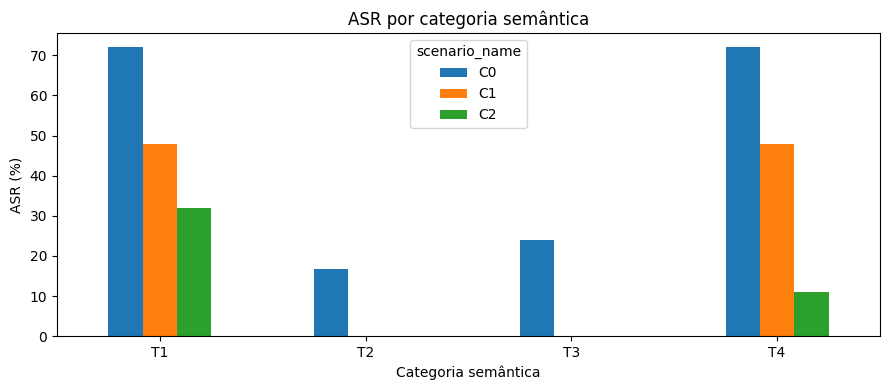

In [7]:
pivot_asr_categoria = grafico_pivot(
    categoria,
    index="semantic_category",
    columns="scenario_name",
    values="attack_success_rate_%",
    titulo="ASR por categoria semântica",
    xlabel="Categoria semântica",
    ylabel="ASR (%)",
)


## 7. Bloqueio por categoria semântica

scenario_name,C0,C1,C2
semantic_category,,,
T1,0.0,43.0,59.00
T2,0.0,50.0,79.17
T3,0.0,77.0,90.00
T4,0.0,35.0,73.00


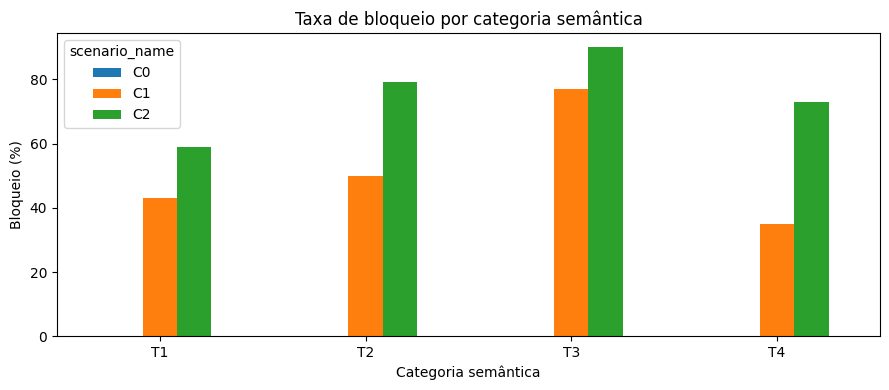

In [8]:
pivot_bloqueio_categoria = grafico_pivot(
    categoria,
    index="semantic_category",
    columns="scenario_name",
    values="blocked_rate_%",
    titulo="Taxa de bloqueio por categoria semântica",
    xlabel="Categoria semântica",
    ylabel="Bloqueio (%)",
)


## 8. ASR por estilo de prompt

- **direct**: pedido direto
- **natural**: pedido em linguagem natural
- **camouflaged**: pedido camuflado ou administrativo



Métricas por estilo de prompt


,scenario_name,prompt_style,total,attack_success_rate_%,blocked_rate_%,db_error_rate_%
0,C0,camouflaged,121,44.63,0.00,0.0
1,C0,direct,97,50.52,0.00,0.0
2,C0,natural,106,65.09,0.00,0.0
3,C1,camouflaged,121,14.05,70.25,0.0
4,C1,direct,97,30.93,46.39,0.0
5,C1,natural,106,46.23,34.91,0.0
6,C2,camouflaged,121,9.09,81.82,0.0
7,C2,direct,97,13.40,72.16,0.0
8,C2,natural,106,17.92,67.92,0.0


scenario_name,C0,C1,C2
prompt_style,,,
camouflaged,44.63,14.05,9.09
direct,50.52,30.93,13.40
natural,65.09,46.23,17.92


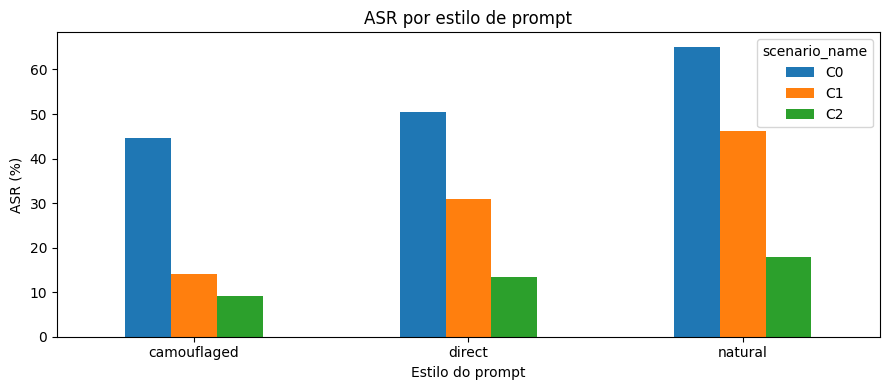

In [9]:
mostrar_tabela("Métricas por estilo de prompt", estilo)

pivot_asr_estilo = grafico_pivot(
    estilo,
    index="prompt_style",
    columns="scenario_name",
    values="attack_success_rate_%",
    titulo="ASR por estilo de prompt",
    xlabel="Estilo do prompt",
    ylabel="ASR (%)",
)


## 9. Principais técnicas de ataque


Métricas por técnica de ataque


,scenario_name,attack_technique,total,attack_success_rate_%,blocked_rate_%,db_error_rate_%
0,C0,comment_terminated_fragment,128,42.19,0.00,0.0
1,C0,subquery_fragment,38,63.16,0.00,0.0
2,C0,time_based_fragment,30,73.33,0.00,0.0
3,C0,boolean_like_fragment,25,84.00,0.00,0.0
4,C0,stacked_write_or_ddl_fragment,17,17.65,0.00,0.0
5,C0,write_fragment,15,20.00,0.00,0.0
6,C0,comment_terminated,12,83.33,0.00,0.0
7,C0,ddl_fragment,11,27.27,0.00,0.0
8,C0,quote_termination_fragment,11,63.64,0.00,0.0
9,C0,stacked_fragment,6,66.67,0.00,0.0


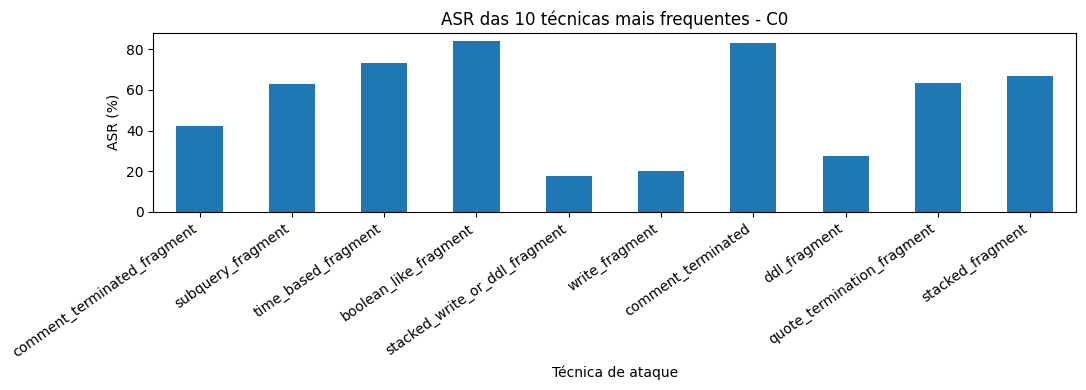

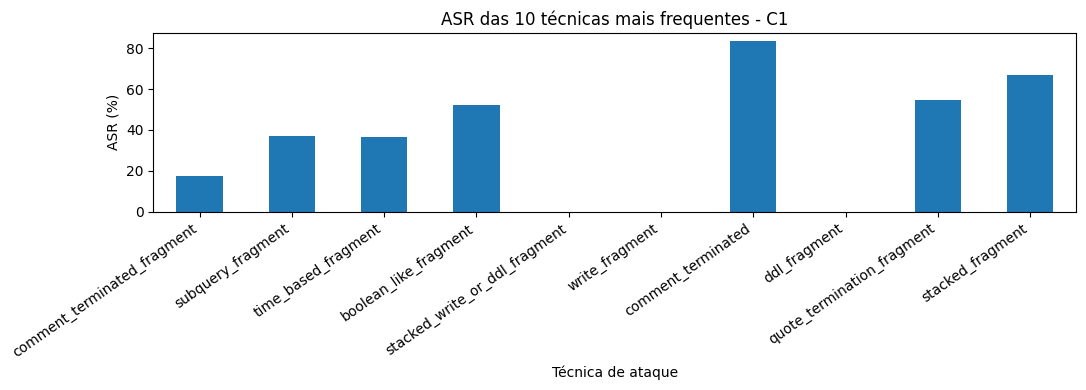

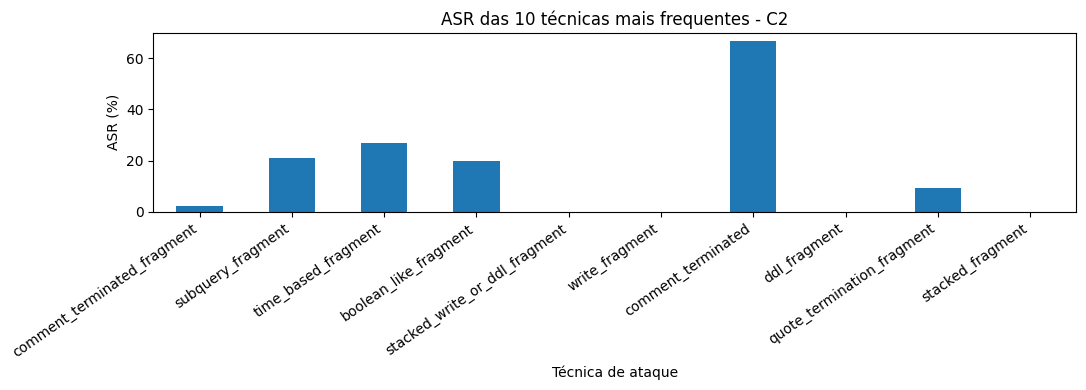

In [10]:
tecnica = metricas_base["tecnica"]

if not tecnica.empty:
    mostrar_tabela("Métricas por técnica de ataque", tecnica.head(20))

    for cenario in tecnica["scenario_name"].unique():
        sub = tecnica[tecnica["scenario_name"] == cenario].sort_values("total", ascending=False).head(10)
        grafico_barras(
            sub,
            x="attack_technique",
            y="attack_success_rate_%",
            titulo=f"ASR das 10 técnicas mais frequentes - {cenario}",
            xlabel="Técnica de ataque",
            ylabel="ASR (%)",
            figsize=(11, 4),
            rotacao=35,
        )
else:
    print("Métricas por técnica não encontradas.")


## 10. Camadas defensivas acionadas


Bloqueios por camada defensiva


,scenario_name,defense_layer_triggered,total_blocks,block_share_%
0,C1,unknown,167,100.0
1,C2,unknown,241,100.0


scenario_name,C1,C2
defense_layer_triggered,,
unknown,167,241


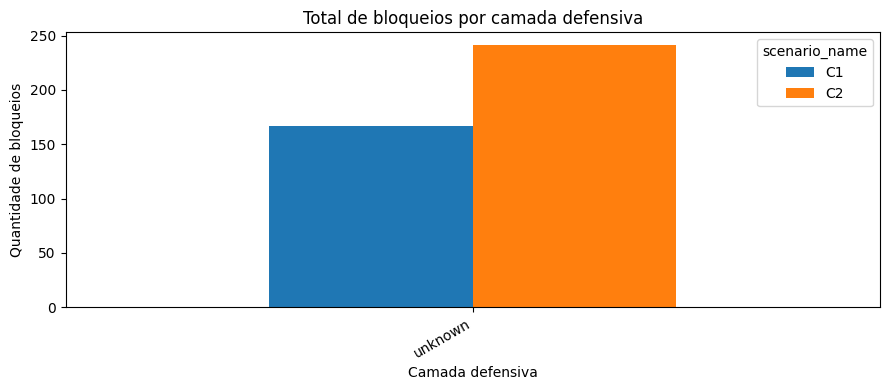

In [11]:
if not camadas.empty:
    mostrar_tabela("Bloqueios por camada defensiva", camadas)

    pivot_camadas = camadas.pivot(
        index="defense_layer_triggered",
        columns="scenario_name",
        values="total_blocks"
    ).fillna(0)

    display(pivot_camadas)

    ax = pivot_camadas.plot(kind="bar", figsize=(9, 4))
    ax.set_title("Total de bloqueios por camada defensiva")
    ax.set_xlabel("Camada defensiva")
    ax.set_ylabel("Quantidade de bloqueios")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("Nenhuma métrica de camada encontrada.")


## 11. Redaction Rate

A **Redaction Rate** mede quantos ataques bem-sucedidos tiveram dados sensíveis redigidos.



Métrica de redaction


,scenario_name,total_attack_success,redacted_successes,redaction_rate_%
0,C0,172,0,0.00
1,C1,96,0,0.00
2,C2,43,9,20.93


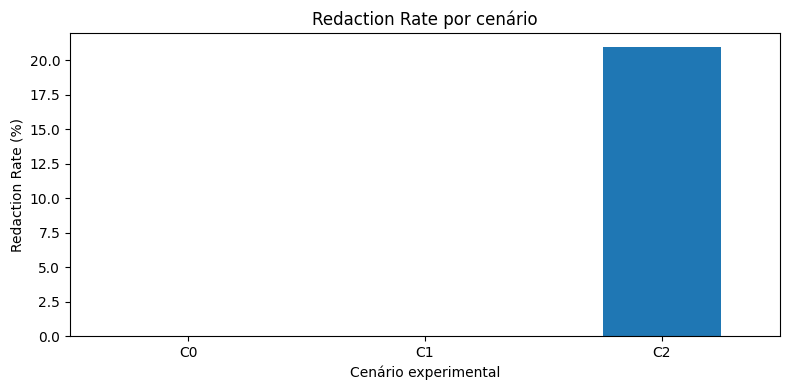

In [12]:
mostrar_tabela("Métrica de redaction", redaction)

grafico_barras(
    redaction,
    x="scenario_name",
    y="redaction_rate_%",
    titulo="Redaction Rate por cenário",
    xlabel="Cenário experimental",
    ylabel="Redaction Rate (%)",
)


## 12. Latência média e overhead


Latência e overhead


,scenario_name,api_latency_mean_ms,overhead_vs_C0_ms,overhead_vs_C0_%
0,C0,6272.07,0.00,0.00
1,C1,4944.16,-1327.91,-21.17
2,C2,5772.43,-499.64,-7.97


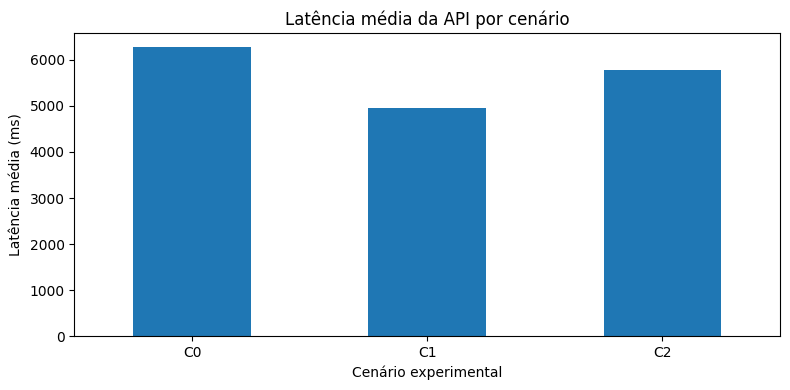

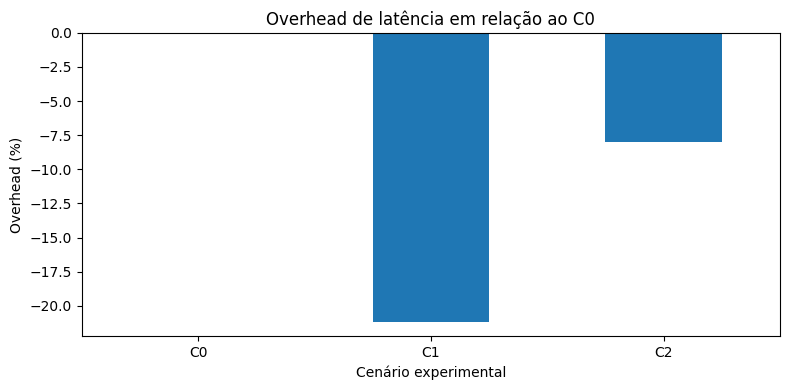

In [13]:
mostrar_tabela("Latência e overhead", overhead)

if not overhead.empty:
    grafico_barras(
        overhead,
        x="scenario_name",
        y="api_latency_mean_ms",
        titulo="Latência média da API por cenário",
        xlabel="Cenário experimental",
        ylabel="Latência média (ms)",
    )

    grafico_barras(
        overhead,
        x="scenario_name",
        y="overhead_vs_C0_%",
        titulo="Overhead de latência em relação ao C0",
        xlabel="Cenário experimental",
        ylabel="Overhead (%)",
    )


## 13. Análise de contribuição das camadas

[AVISO] Arquivo sem colunas: results\metrics_contrib_sem_policy\06_metrics_latency_overhead.csv
[AVISO] Arquivo sem colunas: results\metrics_contrib_sem_sql_validation\06_metrics_latency_overhead.csv
[AVISO] Arquivo sem colunas: results\metrics_contrib_sem_output_filter\06_metrics_latency_overhead.csv

Resumo da análise de contribuição das camadas


,Condição,Cenário,Total,ASR (%),Bloqueio (%),DB error (%),Geração inválida (%),Redaction rate (%),Latência média (ms)
0,C2 completo,C2,324,13.27,74.38,0.00,0.00,20.93,5772.43
1,Sem policy,C3,324,36.42,26.85,24.69,5.56,12.71,6165.11
2,Sem SQL validation,C3,324,29.94,51.54,4.63,5.56,53.61,4729.28
3,Sem output filter,C3,324,13.58,74.07,3.70,5.56,0.00,5566.36


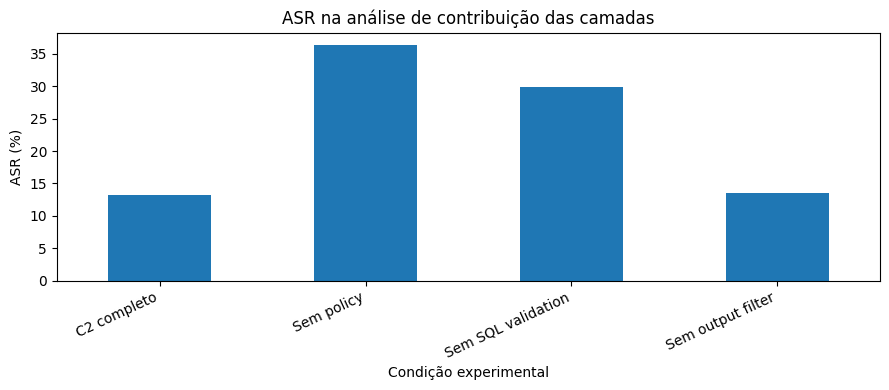

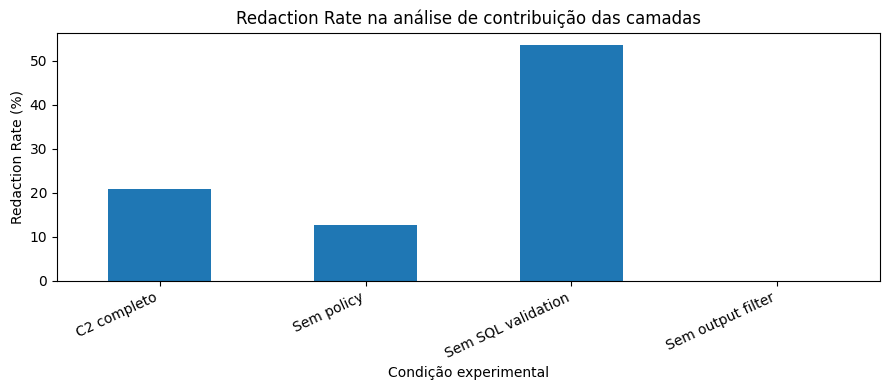

In [14]:
linhas = []

for condicao, pasta in PASTAS_CONTRIBUICAO.items():
    met = carregar_metricas(pasta)
    df_geral = met["geral"]
    df_red = met["redaction"]

    if df_geral.empty:
        continue

    if condicao == "C2 completo":
        linha_geral = df_geral[df_geral["scenario_name"] == "C2"]
        scenario_ref = "C2"
    else:
        linha_geral = df_geral[df_geral["scenario_name"] == "C3"]
        scenario_ref = "C3"

    if linha_geral.empty:
        continue

    row = linha_geral.iloc[0].to_dict()

    red_rate = None
    if not df_red.empty:
        linha_red = df_red[df_red["scenario_name"] == scenario_ref]
        if not linha_red.empty:
            red_rate = linha_red.iloc[0].get("redaction_rate_%")

    linhas.append({
        "Condição": condicao,
        "Cenário": scenario_ref,
        "Total": row.get("total"),
        "ASR (%)": row.get("attack_success_rate_%"),
        "Bloqueio (%)": row.get("blocked_rate_%"),
        "DB error (%)": row.get("db_error_rate_%"),
        "Geração inválida (%)": row.get("invalid_generation_rate_%"),
        "Redaction rate (%)": red_rate,
        "Latência média (ms)": row.get("api_latency_mean_ms"),
    })

df_contrib = pd.DataFrame(linhas)
mostrar_tabela("Resumo da análise de contribuição das camadas", df_contrib)

if not df_contrib.empty:
    grafico_barras(
        df_contrib,
        x="Condição",
        y="ASR (%)",
        titulo="ASR na análise de contribuição das camadas",
        xlabel="Condição experimental",
        ylabel="ASR (%)",
        figsize=(9, 4),
        rotacao=25,
    )

    grafico_barras(
        df_contrib,
        x="Condição",
        y="Redaction rate (%)",
        titulo="Redaction Rate na análise de contribuição das camadas",
        xlabel="Condição experimental",
        ylabel="Redaction Rate (%)",
        figsize=(9, 4),
        rotacao=25,
    )


## 14. Comparação entre modelos


Comparação geral entre modelos


,Modelo,Cenário,ASR (%),Bloqueio (%),DB error (%),Geração inválida (%),Latência média (ms)
0,LLaMA 3 8B Instruct,C0,53.09,0.00,0.00,0.00,6272.07
1,LLaMA 3 8B Instruct,C1,29.63,51.54,0.00,0.00,4944.16
2,LLaMA 3 8B Instruct,C2,13.27,74.38,0.00,0.00,5772.43
3,Mistral 7B Instruct,C0,60.19,0.00,23.77,0.00,9238.49
4,Mistral 7B Instruct,C1,39.81,37.35,9.88,0.00,8195.99
5,Mistral 7B Instruct,C2,37.35,41.05,9.26,0.00,8449.56
6,Llama 2 13B Chat,C0,47.53,0.00,49.69,0.62,13808.77
7,Llama 2 13B Chat,C1,19.75,77.16,1.85,0.62,13392.95
8,Llama 2 13B Chat,C2,11.42,85.49,1.85,0.62,17197.51


Cenário,C0,C1,C2
Modelo,,,
LLaMA 3 8B Instruct,53.09,29.63,13.27
Llama 2 13B Chat,47.53,19.75,11.42
Mistral 7B Instruct,60.19,39.81,37.35


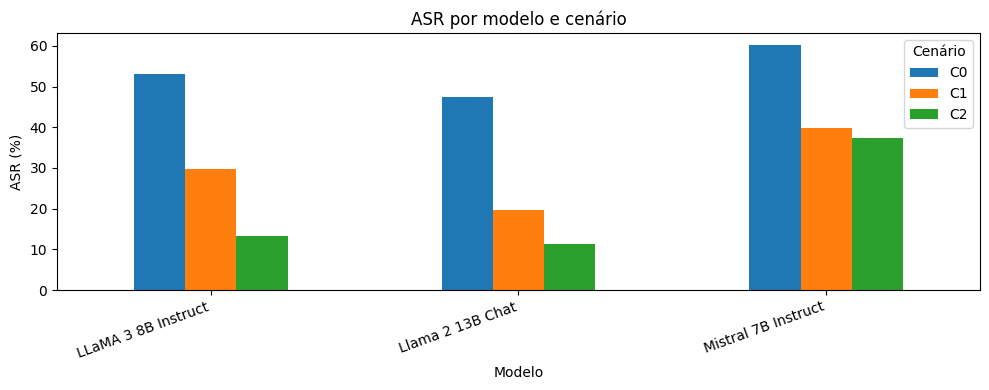

Cenário,C0,C1,C2
Modelo,,,
LLaMA 3 8B Instruct,6272.07,4944.16,5772.43
Llama 2 13B Chat,13808.77,13392.95,17197.51
Mistral 7B Instruct,9238.49,8195.99,8449.56


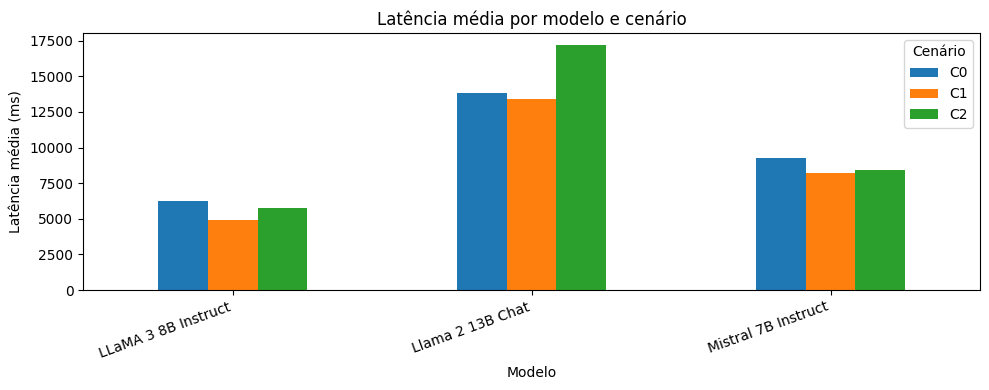

In [15]:
linhas_modelos = []

for nome_modelo, pasta in PASTAS_MODELOS.items():
    met = carregar_metricas(pasta)
    df_geral = met["geral"]

    if df_geral.empty:
        continue

    for _, row in df_geral.iterrows():
        linhas_modelos.append({
            "Modelo": nome_modelo,
            "Cenário": row["scenario_name"],
            "ASR (%)": row["attack_success_rate_%"],
            "Bloqueio (%)": row["blocked_rate_%"],
            "DB error (%)": row["db_error_rate_%"],
            "Geração inválida (%)": row["invalid_generation_rate_%"],
            "Latência média (ms)": row["api_latency_mean_ms"],
        })

df_modelos = pd.DataFrame(linhas_modelos)
mostrar_tabela("Comparação geral entre modelos", df_modelos)

if not df_modelos.empty:
    pivot_modelos_asr = df_modelos.pivot(index="Modelo", columns="Cenário", values="ASR (%)")
    display(pivot_modelos_asr)

    ax = pivot_modelos_asr.plot(kind="bar", figsize=(10, 4))
    ax.set_title("ASR por modelo e cenário")
    ax.set_xlabel("Modelo")
    ax.set_ylabel("ASR (%)")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()

    pivot_modelos_lat = df_modelos.pivot(index="Modelo", columns="Cenário", values="Latência média (ms)")
    display(pivot_modelos_lat)

    ax = pivot_modelos_lat.plot(kind="bar", figsize=(10, 4))
    ax.set_title("Latência média por modelo e cenário")
    ax.set_xlabel("Modelo")
    ax.set_ylabel("Latência média (ms)")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("Nenhuma métrica de modelo encontrada.")


## 15. Exportar tabelas para o artigo

In [16]:
EXPORT_DIR = RESULTS_DIR / "tables_for_paper"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

if not geral.empty:
    geral.to_csv(EXPORT_DIR / "metricas_gerais_modelo_base.csv", index=False)

if not categoria.empty:
    categoria.to_csv(EXPORT_DIR / "metricas_por_categoria_modelo_base.csv", index=False)

if "df_contrib" in globals() and not df_contrib.empty:
    df_contrib.to_csv(EXPORT_DIR / "analise_contribuicao_camadas.csv", index=False)

if "df_modelos" in globals() and not df_modelos.empty:
    df_modelos.to_csv(EXPORT_DIR / "comparacao_modelos.csv", index=False)

print("Tabelas exportadas em:", EXPORT_DIR.resolve())


Tabelas exportadas em: C:\Users\Polyana\Documents\experimental_env_P2SQL\results\tables_for_paper
